# formdiscovery: the `masterrun` demo in Python

This notebook runs the Python port of Kemp & Tenenbaum's `formdiscovery1.0`
([*The discovery of structural form*, PNAS 2008](https://doi.org/10.1073/pnas.0802631105))
on the demo of the original `masterrun.m`: three structural forms (chain, ring, tree)
fitted to three small feature data sets (`demo_chain_feat`, `demo_ring_feat`,
`demo_tree_feat`, each 8 objects × 1000 features). It then

1. compares the scores with the original MATLAB code run in GNU Octave,
2. draws the inferred graphs as `draw_dot.m` does (neato layout, matplotlib),
3. shows MATLAB's progress figures 1-3 during one run,
4. draws the graphs interactively with plotly and pyvis (hover a node: its cluster, or
   a cluster's members), and
5. exports a graph to networkx and GraphML.

Plotly and pyvis are optional: `pip install -e .[interactive]`.

In [1]:
import sys, tempfile
from pathlib import Path

try:
    import formdiscovery
except ImportError:  # not installed: use the repository's src/
    sys.path.insert(0, str(Path.cwd().parent / "src"))
    import formdiscovery

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from formdiscovery.run import masterrun, masterrun_ps
from formdiscovery.viz.draw import ProgressFigures, draw_graph, draw_results
from formdiscovery.viz.networkx_backend import have_graphviz_layout, to_graphml, to_networkx

%matplotlib inline
# the layout draw_dot uses (neato) needs pygraphviz; otherwise networkx's Kamada-Kawai
LAYOUT = "neato" if have_graphviz_layout() else "kamada_kawai"
print("formdiscovery from", Path(formdiscovery.__file__).parent, "| layout:", LAYOUT)

formdiscovery from /home/al/dev/Kemp_Tanembaum_matlab_code/src/formdiscovery | layout: kamada_kawai


## 1. Run the demo

`masterrun()` with its defaults is `masterrun.m`: `ps = defaultps(setps())` with
`reloutsideinit = 'overd'`, structures chain, ring, tree × data sets 1-3, one repeat.
MATLAB seeds `rand('state', rind)`; the port draws its permutations from numpy
(`seed=1`), so the random choices differ from Octave's, but the search finds the same
structures. This takes about half a minute.

In [2]:
ps = masterrun_ps()
res = masterrun(ps, log=print)

  demo_chain_feat chain


  -> ll = -8247.192418, 4 clusters, 2.0 s
  demo_chain_feat ring


  -> ll = -8264.19632, 4 clusters, 2.0 s
  demo_chain_feat tree


  -> ll = -8252.947688, 4 clusters, 6.4 s
  demo_ring_feat chain


  -> ll = -8566.635937, 4 clusters, 1.9 s
  demo_ring_feat ring


  -> ll = -8500.518235, 4 clusters, 2.1 s
  demo_ring_feat tree


  -> ll = -8512.860034, 4 clusters, 5.2 s
  demo_tree_feat chain


  -> ll = -8764.171835, 4 clusters, 2.2 s
  demo_tree_feat ring


  -> ll = -8722.608739, 4 clusters, 2.2 s
  demo_tree_feat tree


  -> ll = -8707.80873, 4 clusters, 8.3 s


## 2. Compare with the original code

`tests/fixtures/masterrun.mat` holds the `modellike` array of `masterrun.m` run in
Octave 10.3 (`tests/octave/fx_masterrun.m`). The scores are log posteriors
(log P(structure, data)); the highest score in each column is the form the model
discovers.

In [3]:
from formdiscovery.io import load_fixture

octave = np.asarray(load_fixture("masterrun")["modellike"], dtype=float)
python = res.modellike[:, :, 0]
print(f"{'data set':18s}{'form':8s}{'Python':>14s}{'Octave':>14s}{'rel. diff':>11s}")
for d in range(3):
    for s in (1, 3, 5):
        p, o = python[s, d], octave[s, d]
        print(f"{ps.data[d]:18s}{ps.structures[s]:8s}{p:14.4f}{o:14.4f}"
              f"{abs(p - o) / abs(o):11.1e}")
for d in range(3):
    best_py = ps.structures[int(np.argmax(np.where(python[:, d] != 0, python[:, d], -np.inf)))]
    best_oc = ps.structures[int(np.argmax(np.where(octave[:, d] != 0, octave[:, d], -np.inf)))]
    print(f"{ps.data[d]}: Python picks {best_py}, Octave picks {best_oc}")

data set          form            Python        Octave  rel. diff
demo_chain_feat   chain       -8247.1924    -8247.2048    1.5e-06
demo_chain_feat   ring        -8264.1963    -8264.2004    4.9e-07
demo_chain_feat   tree        -8252.9477    -8252.8865    7.4e-06
demo_ring_feat    chain       -8566.6359    -8566.6365    6.8e-08
demo_ring_feat    ring        -8500.5182    -8500.5202    2.3e-07
demo_ring_feat    tree        -8512.8600    -8512.8738    1.6e-06
demo_tree_feat    chain       -8764.1718    -8764.1656    7.2e-07
demo_tree_feat    ring        -8722.6087    -8722.5890    2.3e-06
demo_tree_feat    tree        -8707.8087    -8707.8137    5.7e-07
demo_chain_feat: Python picks chain, Octave picks chain
demo_ring_feat: Python picks ring, Octave picks ring
demo_tree_feat: Python picks tree, Octave picks tree


## 3. The inferred graphs

`draw_results` draws the final graph of every run, titled as `runmodel.m` titles its
figure 3 (`'<form>: estimated structure: <score>'`). Object nodes carry the object
names; the unlabelled nodes are the latent cluster nodes. `backend='networkx'` lays the
graph out with neato through networkx when pygraphviz is installed (then the positions
are exactly those of `draw_dot.m`); `backend='pygraphviz'` also reproduces
`graph_draw.m`'s ellipses and arrows.

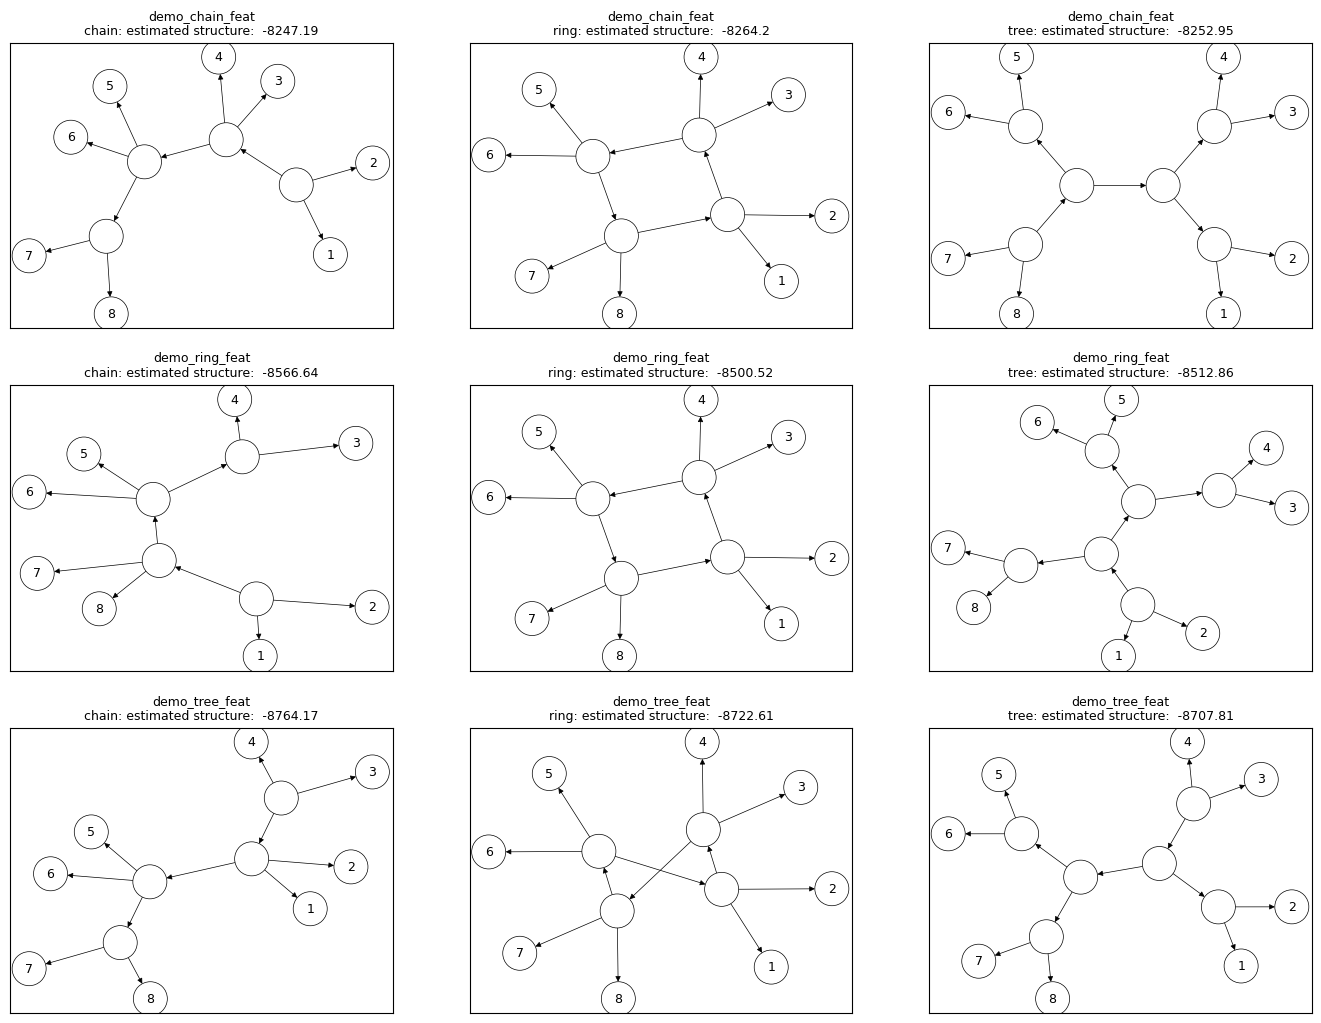

In [4]:
fig = draw_results(res, backend="networkx", layout=LAYOUT)
fig

## 4. Progress figures

With the `ps.show*` flags on, the MATLAB code draws while it searches: figure 1 before
and figure 2 after each clean-up (`gibbs_clean`), figure 3 the best split and the final
graph. `ProgressFigures` is a `show` callback that reproduces them; here it keeps the
last drawing of each figure for the chain on `demo_chain_feat`.

26 drawings: [(2, 'postclean'), (3, 'bestsplit'), (3, 'inferredgraph')]


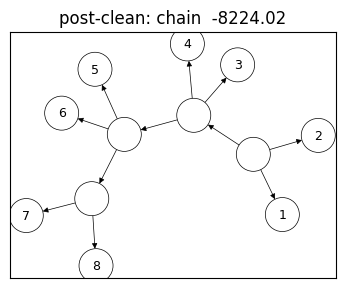

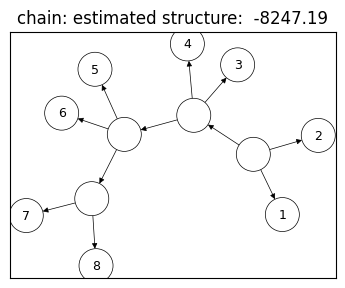

In [5]:
from formdiscovery.run import runmodel

pf = ProgressFigures(backend="networkx", layout=LAYOUT, figsize=(4.2, 3.2))
ps_show = ProgressFigures.enable(masterrun_ps(), ("postclean", "bestsplit", "inferredgraph"))
with tempfile.TemporaryDirectory() as tmp:
    out = runmodel(ps_show, 1, 0, 1, outdir=tmp, rng=1, show=pf)
print(len(pf.calls), "drawings:", sorted({(f, e) for e, f, _, _ in pf.calls}))
for num in sorted(pf.figures):
    display(pf.figures[num])

## 5. Interactive graphs

`draw_graph(graph, names, backend=...)` draws one model graph through the same
`draw_dot` facade. With `backend='plotly'` or `'pyvis'`, hovering a node shows its
hover text: an object's cluster, or a cluster node's members.

### plotly

`draw_results(..., backend='plotly')` puts all nine runs in one interactive figure
(zoom, pan, hover).

In [6]:
import plotly.io as pio

pio.renderers.default = "notebook_connected"  # plotly.js from the CDN keeps the notebook small
figp = draw_results(res, backend="plotly", layout=LAYOUT, panel=(3.6, 3.0))
figp.show()

### pyvis

pyvis (vis-network) draws one graph per page, with the nodes pinned at the layout
positions; drag a node to move it. Here the tree fitted to `demo_tree_feat`.

In [7]:
import html

tree = res.structure[5, 2, 0]
net = draw_graph(tree, res.names[0, 2], backend="pyvis", layout=LAYOUT,
                 title="demo_tree_feat: tree")
page = net.generate_html()
display(HTML(f'<div><iframe srcdoc="{html.escape(page)}" width="720" height="560" '
             'style="border:none"></iframe></div>'))

## 6. Exports

`to_networkx` gives the model graph as a networkx `DiGraph` (node attributes `kind`,
`label`, `cluster_id`; edge attributes `W` and the branch length `weight = 1/W`);
`to_graphml` and `to_dot` write it for Gephi, Cytoscape or Graphviz.

In [8]:
G = to_networkx(tree, res.names[0, 2])
print(G)
print([(v, G.nodes[v]) for v in list(G.nodes)[:3]])
print(list(G.edges(data=True))[:3])
with tempfile.TemporaryDirectory() as tmp:
    path = Path(tmp) / "tree.graphml"
    to_graphml(tree, path, res.names[0, 2])
    print(path.name, path.stat().st_size, "bytes")

DiGraph with 14 nodes and 13 edges
[(0, {'kind': 'object', 'label': '1', 'cluster_id': 1}), (1, {'kind': 'object', 'label': '2', 'cluster_id': 1}), (2, {'kind': 'object', 'label': '3', 'cluster_id': 0})]
[(8, 2, {'W': 6.2116247806642795, 'weight': 0.16098847488548054}), (8, 3, {'W': 5.1528473496526725, 'weight': 0.19406746059873187}), (8, 13, {'W': 1.827717435114941, 'weight': 0.5471305250951508})]
tree.graphml 3989 bytes
